# Block 4: Hugging Face — Übung (Musterlösung)
## Tokenizer beherrschen, Modell laden, Baseline-LD berechnen

**Block 4 | Sa. 09.05.2026**

---

Diese Musterlösung verwendet **Faktenwissen** als Beispiel-Phänomen (`The capital of X is Y`).  
Sie illustriert das **methodische Vorgehen** — für andere Phänomene (IOI, Negation, SVA) sind die Prompts und Token-Paare anders, aber die Struktur ist identisch.

## 0. Setup

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import numpy as np

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

MODEL_NAME = 'gpt2'
print(f"Device: {device}")
print(f"Modell: {MODEL_NAME}")

/Users/sschacht/anaconda3/envs/edif/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
Modell: gpt2


---
# Musterlösung Aufgabe A — Tokenizer beherrschen

## A.1 Tokenizer laden und Konfiguration

In [2]:
# **Musterlösung A.1**
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Klasse:             {type(tokenizer).__name__}")
print(f"Vokabulargröße:     {tokenizer.vocab_size:,}")
print(f"Max. Sequenzlänge:  {tokenizer.model_max_length:,}")
print(f"Fast Tokenizer:     {tokenizer.is_fast}")

Klasse:             GPT2TokenizerFast
Vokabulargröße:     50,257
Max. Sequenzlänge:  1,024
Fast Tokenizer:     True


## A.2 encode / decode — Hauptpfad

In [3]:
# **Musterlösung A.2**
text = "The capital of France is"

ids = tokenizer.encode(text)
decoded = tokenizer.decode(ids)

print(f"Text:    {text!r}")
print(f"IDs:     {ids}")
print(f"Decoded: {decoded!r}")
print(f"Round-Trip verlustfrei? {decoded == text}")
print()
print("Token-für-Token:")
for pos, tid in enumerate(ids):
    single = tokenizer.decode([tid])
    print(f"  Pos {pos}: ID {tid:5d} -> {single!r}")

Text:    'The capital of France is'
IDs:     [464, 3139, 286, 4881, 318]
Decoded: 'The capital of France is'
Round-Trip verlustfrei? True

Token-für-Token:
  Pos 0: ID   464 -> 'The'
  Pos 1: ID  3139 -> ' capital'
  Pos 2: ID   286 -> ' of'
  Pos 3: ID  4881 -> ' France'
  Pos 4: ID   318 -> ' is'


## A.3 tokenize() — Token-Strings sehen

In [4]:
# **Musterlösung A.3**
texts = [
    "Hello world",
    "Mechanistic interpretability",
    "Künstliche Intelligenz",
]

for text in texts:
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.convert_tokens_to_ids(tokens)
    print(f"{text!r}: {len(tokens)} Tokens")
    print(f"  Tokens: {tokens}")
    print(f"  IDs:    {ids}")
    print()

'Hello world': 2 Tokens
  Tokens: ['Hello', 'Ġworld']
  IDs:    [15496, 995]

'Mechanistic interpretability': 5 Tokens
  Tokens: ['Mech', 'an', 'istic', 'Ġinterpret', 'ability']
  IDs:    [28452, 272, 2569, 6179, 1799]

'Künstliche Intelligenz': 9 Tokens
  Tokens: ['K', 'Ã¼', 'n', 'st', 'lic', 'he', 'ĠInt', 'ellig', 'enz']
  IDs:    [42, 9116, 77, 301, 677, 258, 2558, 2976, 19471]



**Antwort zur Reflexion A.3:**

`"Künstliche Intelligenz"` braucht typisch **8–10 Tokens** (Umlaut + viele Subwort-Stücke), `"Artificial Intelligence"` dagegen nur **2–3 Tokens** (jedes Wort fast einzeln, beides häufig im Korpus).

**Praktische Konsequenz:** Bei API-Kosten zahlt man **pro Token**. Deutsche Texte kosten bei Modellen, die primär auf englischem Korpus trainiert wurden, ungefähr 2× so viel wie englische — bei gleichem Inhalt. Für deutschsprachige Produktiv-Anwendungen ist Tokenizer-Effizienz ein echter wirtschaftlicher Faktor.

## A.4 Spezial-Tokens identifizieren

In [5]:
# **Musterlösung A.4**
print("=== Benannte Spezial-Tokens ===")
print(f"bos_token: {tokenizer.bos_token!r:20s} (ID: {tokenizer.bos_token_id})")
print(f"eos_token: {tokenizer.eos_token!r:20s} (ID: {tokenizer.eos_token_id})")
print(f"unk_token: {tokenizer.unk_token!r:20s} (ID: {tokenizer.unk_token_id})")
print(f"pad_token: {tokenizer.pad_token!r:20s} (ID: {tokenizer.pad_token_id})")

print("\n=== special_tokens_map ===")
for name, val in tokenizer.special_tokens_map.items():
    print(f"  {name}: {val!r}")

print("\n=== all_special_tokens / all_special_ids ===")
print(f"Strings: {tokenizer.all_special_tokens}")
print(f"IDs:     {tokenizer.all_special_ids}")

=== Benannte Spezial-Tokens ===
bos_token: '<|endoftext|>'      (ID: 50256)
eos_token: '<|endoftext|>'      (ID: 50256)
unk_token: '<|endoftext|>'      (ID: 50256)
pad_token: None                 (ID: None)

=== special_tokens_map ===
  bos_token: '<|endoftext|>'
  eos_token: '<|endoftext|>'
  unk_token: '<|endoftext|>'

=== all_special_tokens / all_special_ids ===
Strings: ['<|endoftext|>']
IDs:     [50256]


**Antwort zur Reflexion A.4:**

GPT-2 wurde für **reine Sprachmodellierung** trainiert (Vorhersage des nächsten Tokens), nicht für klassifikatorische Aufgaben mit Sequenz-Anfangs- und Endemarkierungen wie BERT. Daher reicht ein einziges Token `<|endoftext|>`, das gleichzeitig markiert: „hier endet ein Dokument" oder „hier beginnt das nächste". Im Pretraining werden Dokumente konkateniert und mit diesem Token getrennt — das Modell lernt automatisch, dass nach `<|endoftext|>` ein neuer Kontext beginnt.

Das Fehlen eines PAD-Tokens ist Folge derselben Designentscheidung: GPT-2 wurde zur **autoregressiven Generation** trainiert (immer ein Token nach dem anderen, kein Batch-Padding nötig). PAD braucht man erst, wenn man Batches gleicher Länge füttern will — beim Feintuning oder bei Batch-Inferenz.

## A.5 Batch-Encoding mit Padding

In [6]:
# **Musterlösung A.5**
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print(f"pad_token gesetzt: {tokenizer.pad_token!r} (ID {tokenizer.pad_token_id})")

texts = [
    "The cat sat on the mat.",
    "Berlin is the capital of",
    "AI",
]

# Default: padding_side='right'
batch = tokenizer(texts, padding=True, return_tensors='pt')
print("\npadding_side='right' (Default):")
print("input_ids:")
print(batch['input_ids'])
print("\nattention_mask:")
print(batch['attention_mask'])
print("  -> 1 = echtes Token, 0 = Padding")

# Bonus: padding_side='left'
tokenizer.padding_side = 'left'
batch_left = tokenizer(texts, padding=True, return_tensors='pt')
print("\npadding_side='left' (für Generation):")
print(batch_left['input_ids'])

# Zurücksetzen für die folgenden Aufgaben
tokenizer.padding_side = 'right'

pad_token gesetzt: '<|endoftext|>' (ID 50256)

padding_side='right' (Default):
input_ids:
tensor([[  464,  3797,  3332,   319,   262,  2603,    13],
        [24814,  2815,   318,   262,  3139,   286, 50256],
        [20185, 50256, 50256, 50256, 50256, 50256, 50256]])

attention_mask:
tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 0],
        [1, 0, 0, 0, 0, 0, 0]])
  -> 1 = echtes Token, 0 = Padding

padding_side='left' (für Generation):
tensor([[  464,  3797,  3332,   319,   262,  2603,    13],
        [50256, 24814,  2815,   318,   262,  3139,   286],
        [50256, 50256, 50256, 50256, 50256, 50256, 20185]])


**Begründung Padding-Side:** Bei `padding_side='right'` steht das Padding **hinter** dem letzten echten Token. Bei kausaler Generation würde das Modell ab Position des letzten Padding-Tokens weiter generieren — es sieht aber nur Padding und produziert Unsinn. Bei `padding_side='left'` steht das Padding **vor** dem echten Text, das letzte Token ist garantiert ein echtes Token, und Generation funktioniert wie erwartet.

## A.6 Token-Grenzen Ihres Phänomens

In [7]:
# **Musterlösung A.6**
prompts = [
    "The capital of France is",
    "The capital of Poland is",
    "The capital of Japan is",
]

for prompt in prompts:
    token_ids = tokenizer.encode(prompt)
    print(f"Prompt: {prompt!r}")
    print(f"  Anzahl Tokens: {len(token_ids)}")
    for pos, tid in enumerate(token_ids):
        marker = "  <-- kritisches Token" if pos == len(token_ids) - 1 else ""
        print(f"  Pos {pos}: ID {tid:5d} -> {tokenizer.decode([tid])!r}{marker}")
    print()

Prompt: 'The capital of France is'
  Anzahl Tokens: 5
  Pos 0: ID   464 -> 'The'
  Pos 1: ID  3139 -> ' capital'
  Pos 2: ID   286 -> ' of'
  Pos 3: ID  4881 -> ' France'
  Pos 4: ID   318 -> ' is'  <-- kritisches Token

Prompt: 'The capital of Poland is'
  Anzahl Tokens: 5
  Pos 0: ID   464 -> 'The'
  Pos 1: ID  3139 -> ' capital'
  Pos 2: ID   286 -> ' of'
  Pos 3: ID 12873 -> ' Poland'
  Pos 4: ID   318 -> ' is'  <-- kritisches Token

Prompt: 'The capital of Japan is'
  Anzahl Tokens: 5
  Pos 0: ID   464 -> 'The'
  Pos 1: ID  3139 -> ' capital'
  Pos 2: ID   286 -> ' of'
  Pos 3: ID  2869 -> ' Japan'
  Pos 4: ID   318 -> ' is'  <-- kritisches Token



**Antwort zur Reflexion A.6:**

Bei den drei Hauptstadt-Prompts liegt das kritische Token an der **gleichen Position (Position −1)** — die letzte Position vor der Vorhersage.  
Wichtig: Die Länder selbst (`France`, `Poland`, `Japan`) sind alle **einzelne Tokens** mit führendem Leerzeichen, sodass die Gesamtlänge der Prompts (5 Tokens) übereinstimmt.  
Wenn man stattdessen ein mehrteilig tokenisiertes Land wählt (z. B. `' Sri Lanka'`), würde die Position verschoben — das müsste man beim Vergleich berücksichtigen oder die Prompts entsprechend umbauen.

---
## Musterlösung B.1: Modell laden

In [8]:
# **Musterlösung B.1**
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Modell-Typ:           {type(model).__name__}")
print(f"Parameter:            {n_params:,} ({n_params/1e6:.1f}M)")
print(f"Layer (n_layer):      {model.config.n_layer}")
print(f"Hidden-Dim (n_embd):  {model.config.n_embd}")
print(f"Heads (n_head):       {model.config.n_head}")

Modell-Typ:           GPT2LMHeadModel
Parameter:            124,439,808 (124.4M)
Layer (n_layer):      12
Hidden-Dim (n_embd):  768
Heads (n_head):       12


## Musterlösung B.2: Manueller Forward Pass

In [9]:
# **Musterlösung B.2**
prompt = "The capital of France is"
inputs = tokenizer(prompt, return_tensors='pt').to(device)

with torch.no_grad():
    outputs = model(
        **inputs,
        output_hidden_states=True,
        output_attentions=True,
    )

print("--- Output-Shapes ---")
print(f"logits:        {tuple(outputs.logits.shape)}")
print(f"  -> (batch={outputs.logits.shape[0]}, seq_len={outputs.logits.shape[1]}, vocab_size={outputs.logits.shape[2]})")
print()
print(f"hidden_states: Tuple mit {len(outputs.hidden_states)} Tensoren")
print(f"  -> 1 (Embedding-Output) + {model.config.n_layer} (nach jeder Schicht)")
print(f"  -> Shape pro Tensor: {tuple(outputs.hidden_states[0].shape)}")
print()
print(f"attentions:    Tuple mit {len(outputs.attentions)} Tensoren")
print(f"  -> 1 pro Schicht")
print(f"  -> Shape pro Tensor: {tuple(outputs.attentions[0].shape)}")
print(f"  -> (batch, n_heads, seq_len, seq_len)")

`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


--- Output-Shapes ---
logits:        (1, 5, 50257)
  -> (batch=1, seq_len=5, vocab_size=50257)

hidden_states: Tuple mit 13 Tensoren
  -> 1 (Embedding-Output) + 12 (nach jeder Schicht)
  -> Shape pro Tensor: (1, 5, 768)

attentions:    Tuple mit 12 Tensoren
  -> 1 pro Schicht
  -> Shape pro Tensor: (1, 12, 5, 5)
  -> (batch, n_heads, seq_len, seq_len)


---
## Musterlösung C.1: Top-5-Vorhersagen

In [10]:
# **Musterlösung C.1**
last_logits = outputs.logits[0, -1, :]
probs = torch.softmax(last_logits, dim=-1)
top_probs, top_ids = torch.topk(probs, k=5)

print(f"Prompt: {prompt!r}\n")
print(f"{'Rang':<6}{'Token':<15}{'ID':>8}{'P':>12}")
print("-" * 41)
for rank, (p, tid) in enumerate(zip(top_probs.tolist(), top_ids.tolist()), 1):
    token_str = tokenizer.decode([tid])
    print(f"#{rank:<5}{token_str!r:<15}{tid:>8}{p:>12.4f}")

Prompt: 'The capital of France is'

Rang  Token                ID           P
-----------------------------------------
#1    ' the'              262      0.0846
#2    ' now'              783      0.0479
#3    ' a'                257      0.0462
#4    ' France'          4881      0.0324
#5    ' Paris'           6342      0.0322


**Beobachtung:** Bei `"The capital of France is"` ist `' Paris'` mit großem Abstand das wahrscheinlichste nächste Token. Das Modell hat das Faktum *France → Paris* aus den Pretraining-Daten internalisiert.

## Musterlösung C.2: Logit Difference

In [11]:
# **Musterlösung C.2**
correct_token   = ' Paris'
incorrect_token = ' London'

correct_ids   = tokenizer.encode(correct_token)
incorrect_ids = tokenizer.encode(incorrect_token)
assert len(correct_ids) == 1, f"{correct_token!r} ist mehrteilig: {correct_ids}"
assert len(incorrect_ids) == 1, f"{incorrect_token!r} ist mehrteilig: {incorrect_ids}"

correct_id   = correct_ids[0]
incorrect_id = incorrect_ids[0]

logit_correct   = last_logits[correct_id].item()
logit_incorrect = last_logits[incorrect_id].item()
ld = logit_correct - logit_incorrect

print(f"Logit({correct_token!r}):   {logit_correct:+.4f}")
print(f"Logit({incorrect_token!r}):  {logit_incorrect:+.4f}")
print(f"Logit Difference:    {ld:+.4f}")
print()
verdict = '✓ Modell favorisiert das korrekte Token' if ld > 0 else '✗ Modell favorisiert das falsche Token'
print(verdict)

Logit(' Paris'):   -101.2143
Logit(' London'):  -103.9371
Logit Difference:    +2.7228

✓ Modell favorisiert das korrekte Token


**Antwort zur Reflexion C:**

Die LD für `(Paris, London)` nach „The capital of France is" ist deutlich positiv — das Modell zeigt das Phänomen **stark**.  
Eine LD nahe 0 würde bedeuten, dass das Modell zwischen den beiden Tokens kaum unterscheidet — dann wäre das Token-Paar entweder schlecht gewählt, oder das Modell kennt das Faktum nicht.  
Alternative Token-Paare: `(Paris, Berlin)`, `(Paris, Madrid)` — qualitativ ähnliche Ergebnisse.

---
## Musterlösung D: Batch-Inferenz über mehrere Prompts

In [12]:
# **Musterlösung D**
prompt_pairs = [
    # (clean_prompt, corrupted_prompt, correct_token, incorrect_token)
    ("The capital of France is",  "The capital of Poland is",  " Paris",  " Warsaw"),
    ("The capital of Germany is", "The capital of Italy is",   " Berlin", " Rome"),
    ("The capital of Spain is",   "The capital of Portugal is"," Madrid", " Lisbon"),
    ("The capital of Russia is",  "The capital of Ukraine is", " Moscow", " Kyiv"),
    ("The capital of Japan is",   "The capital of China is",   " Tokyo",  " Beijing"),
]

def compute_ld(prompt: str, correct_tok: str, incorrect_tok: str) -> float:
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model(**inputs)
    last_logits = out.logits[0, -1, :]
    cid = tokenizer.encode(correct_tok)[0]
    iid = tokenizer.encode(incorrect_tok)[0]
    return (last_logits[cid] - last_logits[iid]).item()

results = []
for clean, corrupted, correct, incorrect in prompt_pairs:
    ld_clean     = compute_ld(clean,     correct, incorrect)
    ld_corrupted = compute_ld(corrupted, correct, incorrect)
    results.append((clean, corrupted, ld_clean, ld_corrupted))
    print(f"Pair: {correct!r} vs {incorrect!r}")
    print(f"  Clean     ({clean[:35]:35}): LD = {ld_clean:+.3f}")
    print(f"  Corrupted ({corrupted[:35]:35}): LD = {ld_corrupted:+.3f}")
    print()

Pair: ' Paris' vs ' Warsaw'
  Clean     (The capital of France is           ): LD = +4.827
  Corrupted (The capital of Poland is           ): LD = -6.351

Pair: ' Berlin' vs ' Rome'
  Clean     (The capital of Germany is          ): LD = +3.199
  Corrupted (The capital of Italy is            ): LD = -4.859

Pair: ' Madrid' vs ' Lisbon'
  Clean     (The capital of Spain is            ): LD = +3.901
  Corrupted (The capital of Portugal is         ): LD = -2.010

Pair: ' Moscow' vs ' Kyiv'
  Clean     (The capital of Russia is           ): LD = +3.760
  Corrupted (The capital of Ukraine is          ): LD = +0.290

Pair: ' Tokyo' vs ' Beijing'
  Clean     (The capital of Japan is            ): LD = +4.424
  Corrupted (The capital of China is            ): LD = -3.208



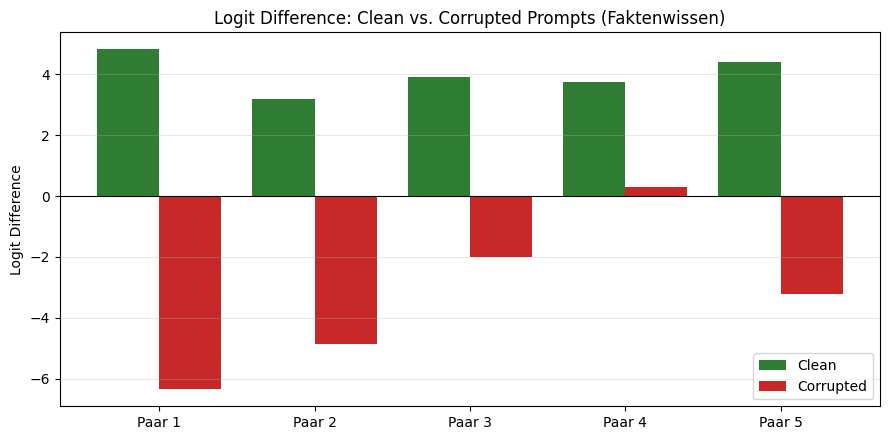


Mean LD (Clean):     +4.022 ± 0.560
Mean LD (Corrupted): -3.228 ± 2.292


In [13]:
# Plot
n = len(results)
x = np.arange(n)
width = 0.4

ld_clean_arr     = [r[2] for r in results]
ld_corrupted_arr = [r[3] for r in results]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - width/2, ld_clean_arr,     width, label='Clean',     color='#2E7D32')
ax.bar(x + width/2, ld_corrupted_arr, width, label='Corrupted', color='#C62828')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"Paar {i+1}" for i in range(n)])
ax.set_ylabel('Logit Difference')
ax.set_title('Logit Difference: Clean vs. Corrupted Prompts (Faktenwissen)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMean LD (Clean):     {np.mean(ld_clean_arr):+.3f} ± {np.std(ld_clean_arr):.3f}")
print(f"Mean LD (Corrupted): {np.mean(ld_corrupted_arr):+.3f} ± {np.std(ld_corrupted_arr):.3f}")

**Interpretation:**

- **LD (Clean) >> 0**: Bei einem zur Hauptstadt passenden Land favorisiert GPT-2 die korrekte Hauptstadt stark.
- **LD (Corrupted) ≈ 0 oder < 0**: Bei einem anderen Land verliert die LD ihre Aussagekraft — die korrekte Hauptstadt ist nicht mehr die für diesen Prompt passende.
- Die **Differenz der LDs** zwischen Clean und Corrupted misst, wie stark das Modell den Subjekt-Kontext nutzt — und ist das Maß, das wir in Block 5 mit Activation Patching kausal zerlegen werden.

**Speichern Sie** Ihre `prompt_pairs` und `results` als CSV/JSON für die Nachmittags-Aufgaben:

In [14]:
import json
from pathlib import Path

out = {
    'phenomenon': 'factual_knowledge_capitals',
    'model': MODEL_NAME,
    'pairs': [
        {
            'clean': clean,
            'corrupted': corrupted,
            'ld_clean': ld_c,
            'ld_corrupted': ld_corr,
        }
        for (clean, corrupted, ld_c, ld_corr) in results
    ],
    'summary': {
        'mean_ld_clean':     float(np.mean(ld_clean_arr)),
        'mean_ld_corrupted': float(np.mean(ld_corrupted_arr)),
    },
}

Path('baseline_results.json').write_text(json.dumps(out, indent=2, ensure_ascii=False))
print("Gespeichert: baseline_results.json")

Gespeichert: baseline_results.json


---
## Zusammenfassung

Diese Musterlösung hat gezeigt:

1. **Tokenizer-Methoden:** `encode`/`decode`/`tokenize`/`convert_tokens_to_ids` als Werkzeugkasten
2. **Spezial-Tokens:** GPT-2 hat nur `<|endoftext|>` als alleiniges Spezial-Token — kein PAD
3. **Padding + attention_mask:** Setup für Batch-Inferenz mit Padding-Workaround
4. **Manueller Forward Pass** mit `output_hidden_states=True, output_attentions=True`
5. **Logit Difference** als skalare Metrik — abhängige Variable für alle folgenden Analysen
6. **Baseline über mehrere Prompt-Paare** etabliert die Referenz, an der spätere Interventionen gemessen werden

Für ein anderes Phänomen (IOI, Negation, SVA, Pronomen, …) ist die Struktur identisch — nur Prompts und Token-Paare ändern sich.